# Intro-to-Astro Week 3
## NASA Exoplanet Archive Assignment

This week, we learned about exoplanet detection methods and explored the NASA Exoplanet Archive together. In this assignment, you will practice using Exoplanet Archive by downloading data and creating some informative plots. 

### Part 1: Finding your data
Launch the NASA Exoplanet Archive at [this link](https://exoplanetarchive.ipac.caltech.edu/). Before we get into data manipulation with Python, let's check out some of the utility of the online portal. Navigate to the "Planetary Systems Composite Data" table.

List the first 3 authors who discovered TOI-6324 b:

    Lee, Rena A.
    Dai, Fei search
    Howard, Andrew W.



How many systems list position information (RA, Dec) from sources that are not the TICv8 (TESS Input Catalog)?
- 264 system list position information (RA, Dec) from sources that are not the TICv8.

Explore one of these position reference papers. What was the purpose of their survey?
- @author = {{Lee}, Rena A. and {Dai}, Fei and {Howard}, Andrew W. and {Halverson}, Samuel and {Gomez Barrientos}, Jonathan and {Greklek-McKeon}, Michael and {Knutson}, Heather A. and {Fulton}, Benjamin J. and {Stef{'a}nsson}, Gu{\dj}mundur and {Lubin}, Jack and {Isaacson}, Howard and {Brinkman}, Casey L. and {Saunders}, Nicholas and {Hey}, Daniel and {Huber}, Daniel and {Weiss}, Lauren M. and {Rogers}, Leslie A. and {Valencia}, Diana and {Plotnykov}, Mykhaylo and {Paragas}, Kimberly and {Hu}, Renyu and {Han}, Te and {Petigura}, Erik A. and {Rubenzahl}, Ryan and {Ciardi}, David R. and {Householder}, Aaron and {Gilbert}, Gregory J. and {Ong}, J.M. Joel and {Zhang}, Jingwen and {Luhn}, Jacob and {Handley}, Luke and {Beard}, Corey and {Giacalone}, Steven and {Holcomb}, Rae and {Van Zandt}, Judah and {Baker}, Ashley D. and {Brodheim}, Max and {Brown}, Matt and {Charbonneau}, David and {Collins}, Karen A. and {Crossfield}, Ian J.~M. and {Deich}, William and {Dumusque}, Xavier and {Gibson}, Steven R. and {Gilbert}, Emily and {Hill}, Grant M. and {Holden}, Bradford and {Jenkins}, Jon M. and {Kaye}, Stephen and {Laher}, Russ R. and {Lanclos}, Kyle and {Levine}, W. Garett and {Payne}, Joel and {Polanski}, Alex S. and {O'Meara}, John and {Ricker}, George R. and {Rider}, Kodi and {Robertson}, Paul and {Roy}, Arpita and {Schlieder}, Joshua E. and {Schwab}, Christian and {Seager}, Sara and {Shaum}, Abby P. and {Sirk}, Martin M. and {Striegel}, Stephanie and {Teske}, Johanna and {Valliant}, John and {Vanderspek}, Roland and {Vasisht}, Gautam and {Walawender}, Josh and {Wang}, Sharon Xuesong and {Winn}, Joshua N. and {Wishnow}, Edward and {Yeh}, Sherry}, title = "{TOI-6324 b: An Earth-mass Ultra-short-period Planet Transiting a Nearby M Dwarf}", journal = {\apjl}, keywords = {Exoplanet structure, Exoplanets, Radial velocity, Exoplanet astronomy, 495, 498, 1332, 486, Astrophysics - Earth and Planetary Astrophysics}, year = 2025, month = apr, volume = {983}, number = {2}, eid = {L36}, pages = {L36}, doi = {10.3847/2041-8213/adadd7}, archivePrefix = {arXiv}, eprint = {2502.16087}, primaryClass = {astro-ph.EP}, adsurl = {https://ui.adsabs.harvard.edu/abs/2025ApJ...983L..36L}, adsnote = {Provided by the SAO/NASA Astrophysics Data System} }

Now that we have poked around online, let's download the data and plot it. Reset the table by refreshing the page, so your filters and selections are removed. Select "Download Table" and save to your data directory. This CSV file holds information on all the currently confirmed exoplanets. Follow the code prompts below to read in this data file.

In [3]:
# To start, let's import the necessary libraries for this assignment.

import os                           # for file and directory operations
import pandas as pd                 # for data manipulation and analysis
import matplotlib.pyplot as plt     # for plotting data
import numpy as np                  # for numerical operations

# to display plots inline in Jupyter Notebook, use this 'magic command':
%matplotlib inline

In [5]:
# Reading Data

path = 'PSCompPars_2025.07.20_06.02.21.csv' # replace with your actual data file name

# Read the CSV file into a DataFrame
df = pd.read_csv(path, comment='#')
df # let's see what our data table looks like

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_id,sy_snum,sy_pnum,...,sy_kepmagerr1,sy_kepmagerr2,sy_kepmag_reflink,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,2,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,2.0,1.0,2.0,0.0,0.0,0.0,0.0
1,2,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,1,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,3,14 And b,14 And,b,HD 221345,HIP 116076,TIC 333225860,Gaia DR2 1920113512486282240,1,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,4,14 Her b,14 Her,b,HD 145675,HIP 79248,TIC 219483057,Gaia DR2 1385293808145621504,1,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0.0,1.0,4.0,1.0,0.0,0.0,0.0
4,5,16 Cyg B b,16 Cyg B,b,HD 186427,HIP 96901,TIC 27533327,Gaia DR2 2135550755683407232,3,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5.0,1.0,4.0,3.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5928,5929,ups And b,ups And,b,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,2,3,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5.0,1.0,10.0,1.0,0.0,0.0,0.0
5929,5930,ups And c,ups And,c,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,2,3,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5.0,1.0,10.0,1.0,0.0,0.0,0.0
5930,5931,ups And d,ups And,d,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,2,3,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5.0,1.0,10.0,1.0,0.0,0.0,0.0
5931,5932,ups Leo b,ups Leo,b,NaN,NaN,TIC 49430557,Gaia DR2 3794167001116433152,1,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Let's see what columns are available in the DataFrame
print(df.columns) # Note: descriptions of the columns can be found in the beginning of the CSV file

Index(['rowid', 'pl_name', 'hostname', 'pl_letter', 'hd_name', 'hip_name',
       'tic_id', 'gaia_id', 'sy_snum', 'sy_pnum',
       ...
       'sy_kepmagerr1', 'sy_kepmagerr2', 'sy_kepmag_reflink', 'pl_nnotes',
       'st_nphot', 'st_nrvc', 'st_nspec', 'pl_nespec', 'pl_ntranspec',
       'pl_ndispec'],
      dtype='object', length=319)


In the following code cells, create and print variables that will provide some information about our data table, such as the number of planets in the table, the discovery facilities, etc.

In [12]:
# How many planets are in the table?
names=df['pl_name'] #the first column of the csv described the names of the planet
#eventhough it shows 5932, there is a possibility that some planets are named more than once. So, we have to remve them
names_list=names.tolist()
names_list_unique=list(set(names_list))
number=len(names_list_unique)
print(number)

5933


In [14]:
# How many discovery facilities are listed in the table?
number_disc= len(list(set(df['disc_facility'].tolist()))) #repeating same strategy
print(number_disc)

73


### Part 2: Plotting your data

Now that we have taken a look at the data table, let's start using it! We can recreate one of the plots we looked at together on Exoplanet Archive as a quick example.

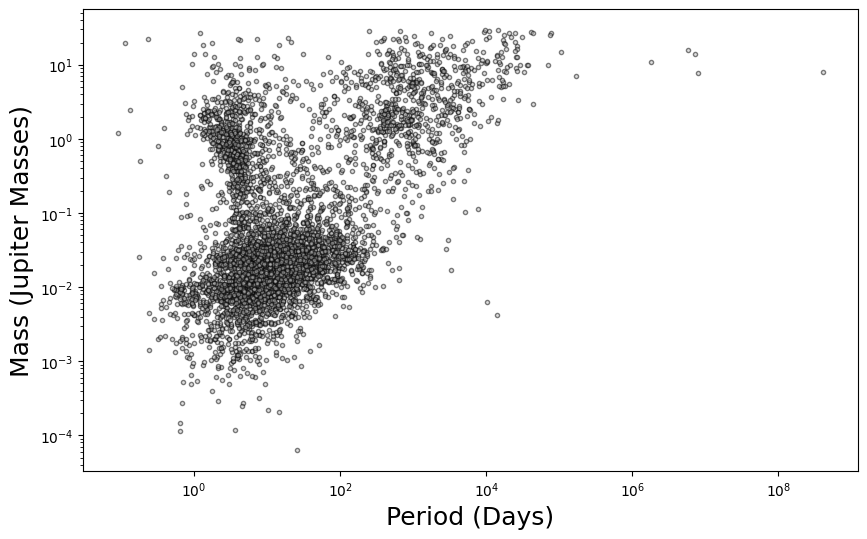

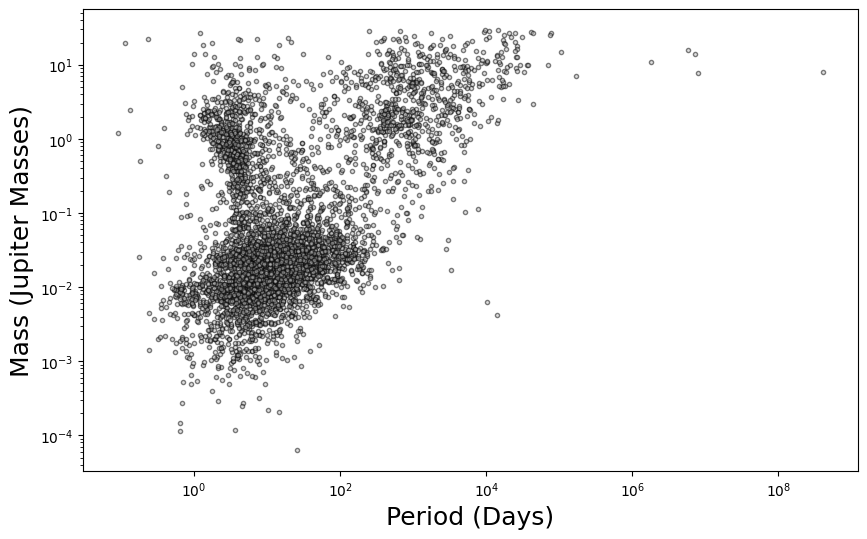

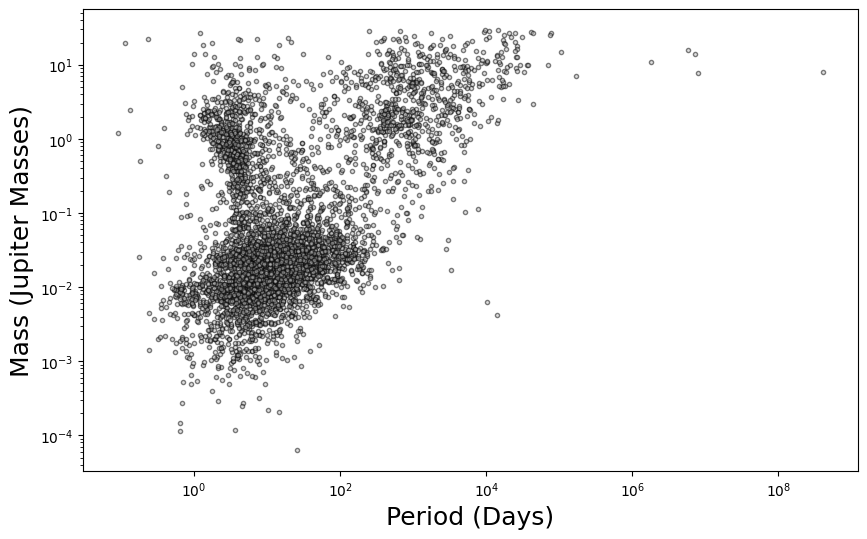

In [20]:
# create a scatter plot of Period (Days) vs Mass (Jupiter Masses) 

# create a figure object and set its size
plt.figure(figsize=(10, 6))
# plot the relevant columns from the DataFrame.
plt.scatter(df['pl_orbper'], df['pl_bmassj'], alpha=0.5, color='silver', edgecolor='k', marker='.')
# set the x and y scales to logarithmic so that we can see the data better
plt.xscale('log')
plt.yscale('log')
# label your axes
plt.xlabel('Period (Days)', fontsize=18)
plt.ylabel('Mass (Jupiter Masses)', fontsize=18)
# finally, show the plot
plt.show()

The above plot shows us the distribution of planet masses and periods like the one on Exoplanet Archive. However, we can take it a step further and distinguish the points according to their discovery method, like the plot online.

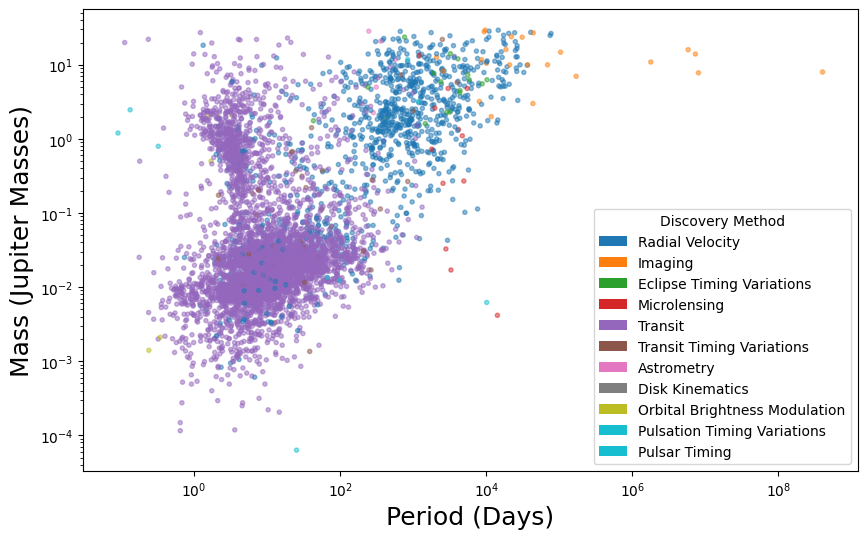

In [45]:
# Taking the same setup as above, but now we will color the points by discovery method
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Period (Days)', fontsize=18)
plt.ylabel('Mass (Jupiter Masses)', fontsize=18)
# convert discovery methods to numeric codes for coloring, and hold labels
discmethods = df['discoverymethod']
dm_num = pd.factorize(discmethods)[0]
# use the 'c' parameter to color the points by discovery method
cmap = plt.cm.tab10 # choose a colormap
colors = cmap(dm_num / dm_num.max())  # normalize the numeric codes for color mapping
plt.scatter(df['pl_orbper'], df['pl_bmassj'], c=colors, alpha=0.5, marker='.') #plot data
# add a legend to indicate which color corresponds to which discovery method
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i/dm_num.max()), label=label) for i, label in enumerate(discmethods.unique())]
plt.legend(handles=legend_elements, title='Discovery Method', loc='lower right')
plt.show()

Now that you've seen an example, recreate another plot that was already generated on the NASA Exoplanet archive.

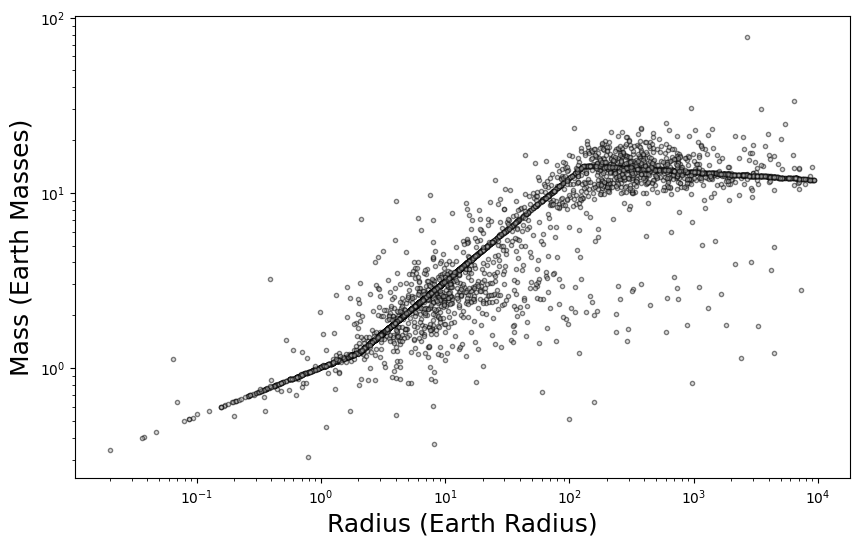

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(df['pl_bmasse'], df['pl_rade'], alpha=0.5, color='silver', edgecolor='k', marker='.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radius (Earth Radius)', fontsize=18)
plt.ylabel('Mass (Earth Masses)', fontsize=18)
plt.show()

#It shows planetary composition transitions. You’re visually catching the difference between terrestrial and gas/ice giant regimes.

### Part 3: Filtering your data

We saw during the live session that we can filter the data table to include only a subset of planets that we're particularly interested in. Since we downloaded all systems already, we can also filter them here. Let's explore the different kinds of planets that have been discovered by TESS and Kepler, the two main transiting planet missions.

In [26]:
# create Boolean masks to filter the DataFrame for planets discovered by TESS and by Kepler
tess_mask = df['disc_facility'].str.contains('TESS', case=False, na=False)
kepler_mask = df['disc_facility'].str.contains('Kepler', case=False, na=False)

# filter the DataFrame using the masks
tess_planets = df[tess_mask]
kepler_planets = df[kepler_mask]

# How many planets were discovered by TESS and Kepler?
number_kepler=len(kepler_planets)
number_tess=len(tess_planets)
print(f'{number_kepler} planets were discovered by Kepler method whereas {number_tess} planets by TESS planets.')

2784 planets were discovered by Kepler method whereas 643 planets by TESS planets.


Let's compare the different planet populations discovered by Kepler and by TESS. 

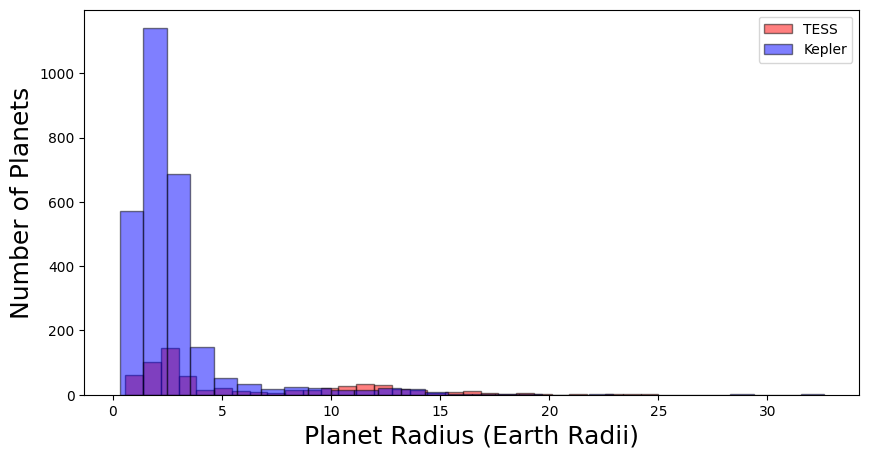

In [49]:
# create a histogram of planet radii for TESS and Kepler planets in Earth radii
plt.figure(figsize=(10, 5))
# plot the data
plt.hist(tess_planets['pl_rade'], bins=30, alpha=0.5, label='TESS', color='red', edgecolor='black')
plt.hist(kepler_planets['pl_rade'], bins=30, alpha=0.5, label='Kepler', color='blue', edgecolor='black')
plt.xlabel('Planet Radius (Earth Radii)',fontsize=18)
plt.ylabel('Number of Planets',fontsize=18)
plt.legend()
plt.show()

Let's improve this histogram to create a more informative visual comparison of the two distributions. We can assign common bins and set the axes to logarithmic scales, for example.

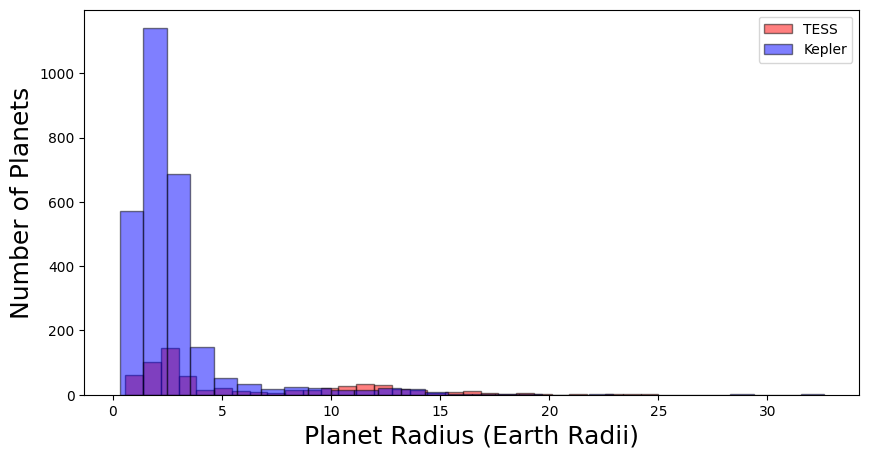

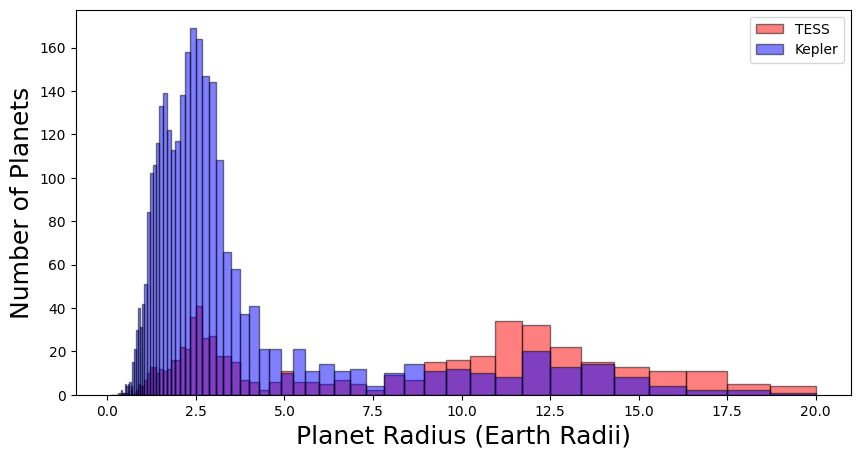

In [30]:
plt.figure(figsize=(10, 5))

# define informative bins for the histogram
bins = np.logspace(np.log10(0.1), np.log10(20), 80) 

# finish on your own
plt.hist(tess_planets['pl_rade'], bins=bins, alpha=0.5, label='TESS', color='red', edgecolor='black')
plt.hist(kepler_planets['pl_rade'], bins=bins, alpha=0.5, label='Kepler', color='blue', edgecolor='black')
plt.xlabel('Planet Radius (Earth Radii)',fontsize=18)
plt.ylabel('Number of Planets',fontsize=18)
plt.legend()
plt.show()

What are the most notable differences between the two distributions? What are the similarities? Try re-plotting a 'zoomed-in' section of the above histogram to better view the 'radius valley'.

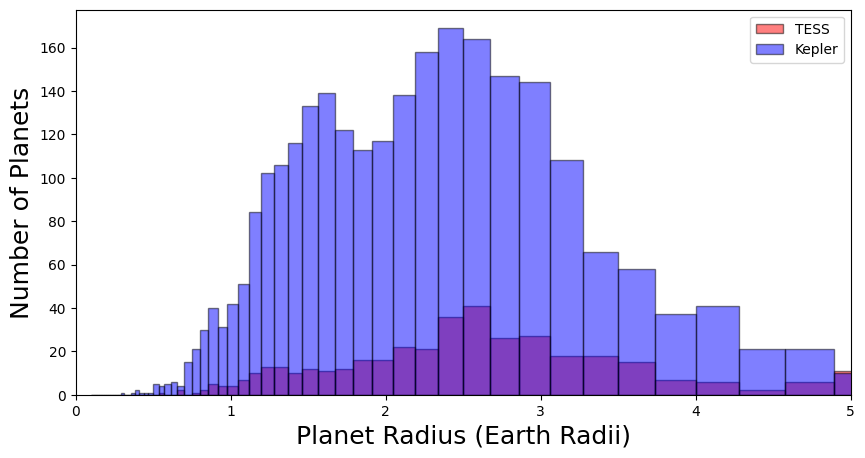

In [32]:
plt.figure(figsize=(10, 5)) 
plt.hist(tess_planets['pl_rade'], bins=bins, alpha=0.5, label='TESS', color='red', edgecolor='black')
plt.hist(kepler_planets['pl_rade'], bins=bins, alpha=0.5, label='Kepler', color='blue', edgecolor='black')
plt.xlabel('Planet Radius (Earth Radii)',fontsize=18)
plt.ylabel('Number of Planets',fontsize=18)
plt.legend()
plt.xlim(0,5)
plt.show()

Use different filters and functions on the data table to answer the following questions:
- How many planets were discovered using the Radial Velocity method?
- How far away is the furthest confirmed exoplanet? What is its name?
- How many planets are smaller than the Earth?

In [34]:
# create a mask for planets discovered by the Radial Velocity method
radialvelocity_number = len(df[df['discoverymethod'].str.contains('Radial Velocity', case=False, na=False)])
print(f'Number of planets discovered by Radial Velocity method: {radialvelocity_number}')

# find the furthest confirmed exoplanet
pl_distance=df.loc[df['sy_dist'].idxmax()]['sy_dist']
pl_name=df.loc[df['sy_dist'].idxmax()]['pl_name']
print(f'{pl_name} at {pl_distance} parsecs distance is the farthest planet.')

# count the number of planets smaller than Earth
n_earthsmall=len(df[df['pl_rade']<1])
print(f'There are {n_earthsmall} planets with radius smaller than that of the Earth.')


Number of planets discovered by Radial Velocity method: 1128
SWEEPS-11 b at 8500.0 parsecs distance is the farthest planet.
There are 224 planets with radius smaller than that of the Earth.


Now that we've had some practice, try out the following exercise. Select only planets that have mass measurements using the same Boolean mask method we did earlier. Then, select a subset of the planets with mass mesurements that also have planet radius measurements (i.e., planet radius and mass columns are not empty/NaN). 

In [36]:
# create a mask for planets with mass measurements
mass_mask = df['pl_bmasse'].notna()
selected_planets = df[mass_mask]

# create a mask for planets that also have planet radius measurements (i.e., planet radius column is not empty/NaN!)
radius_mask = selected_planets.notna()
selected_planets2 = selected_planets[radius_mask]

# how many planets were discovered by the Radial Velocity method?
radialvelocity_number1 = len(selected_planets[selected_planets['discoverymethod'].str.contains('Radial Velocity', case=False, na=False)])
print(f'Number of such planets discovered by Radial Velocity method: {radialvelocity_number1}')

# how many of those have planet radius measurements?
radialvelocity_number2 = len(selected_planets2[selected_planets2['discoverymethod'].str.contains('Radial Velocity', case=False, na=False)])
print(f'Number of such planets discovered by Radial Velocity method: {radialvelocity_number2}')


Number of such planets discovered by Radial Velocity method: 1126
Number of such planets discovered by Radial Velocity method: 1126


Now that we have our filtered data, let's make a plot that informs us about this subset of planets. Make a Planet Density (g/cm^3) vs. Planet Radius (Earth Radius) plot. The unit conversions have been coded for you using the astropy package.

In [38]:
import astropy.units as u

# convert planet radius from Earth radii to centimeters
rad_cm = selected_planets['pl_rade'] * u.R_earth.to(u.cm)

# convert planet mass from Earth masses to g
mass_g = selected_planets['pl_bmasse'] * u.M_earth.to(u.g)

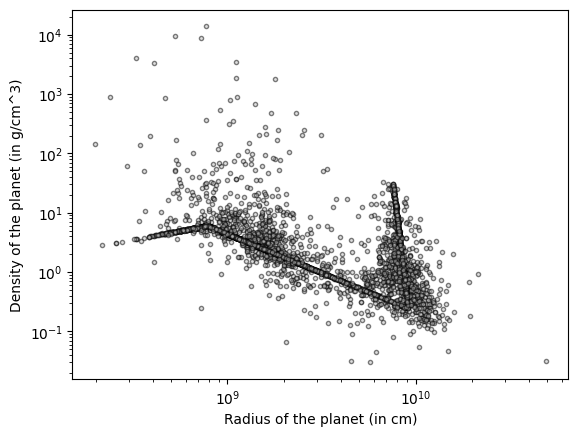

In [40]:
# calculate density in g/cm^3
density_gcm3= mass_g/((4/3)*np.pi*(rad_cm**3))

# create a scatter plot of Density (g/cm^3) vs Planet Radius (Earth Radii)
plt.scatter(rad_cm, density_gcm3, alpha=0.5, color='silver', edgecolor='k', marker='.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radius of the planet (in cm)')
plt.ylabel('Density of the planet (in g/cm^3)')
plt.show()

### Part 4: Choose your own adventure

Using the various things you've learned throughout this tutorial and assignment, create a plot to visualize the correlation between any parameters of your choosing. Choose a specific and interesting subset of planets (e.g., planets discovered via the radial velocity method, nearby planets, etc.). Write down some interesting things you learned from your plot. 

There are total 5897 with proper mass and radius estimated.

List of all methods by which planets have been detected: Radial Velocity, Transit Timing Variations, Eclipse Timing Variations, Astrometry, Imaging, Disk Kinematics, Orbital Brightness Modulation, Pulsar Timing, Transit, Pulsation Timing Variations, Microlensing

There are total 1126 with proper estimated mass and radius, discovered by Transit method.


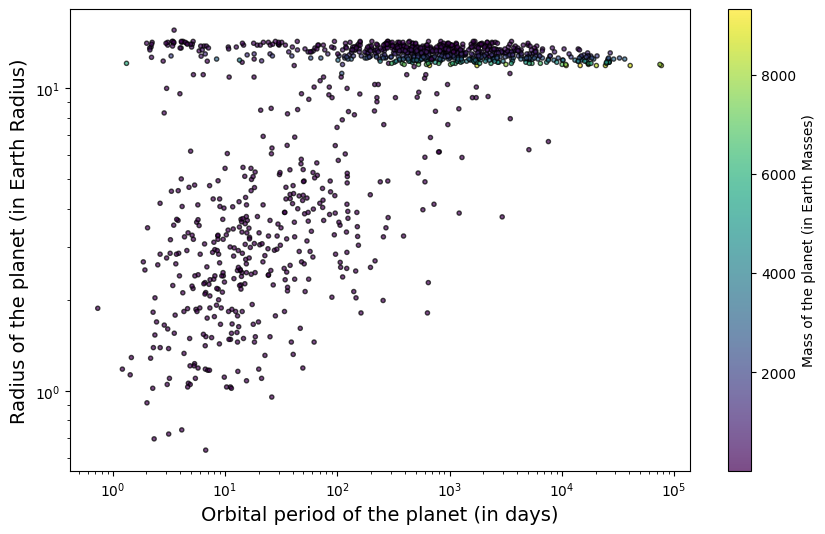


We can observe that planets with higher radius and higher orbital period are more detected. As the graph is plot for the transit method, larger planets are more detectable as they block more light and planets with shorter period are more detected as they are easier to confirm. A upper ridge can be observed at the plot, however it is not understood what could be reason behind the occurence of this ridge. Most planets are low-mass models.


In [42]:
planets0=df[df['pl_bmasse'].notna()][df[df['pl_bmasse'].notna()].notna()]
number_planets0=len(planets0)
print(f'There are total {number_planets0} with proper mass and radius estimated.')
#What are all the methods?
methods=', '.join(list(set(list(df['discoverymethod']))))
print('\nList of all methods by which planets have been detected:', methods)
#I am interested in Transit method. So lets do the filteration.
transit_planet0 = planets0[planets0['discoverymethod'].str.contains('Radial Velocity', case=False, na=False)]
print(f'\nThere are total {len(transit_planet0)} with proper estimated mass and radius, discovered by Transit method.') #That's a lot actual.

plt.figure(figsize=(10, 6))

sc = plt.scatter(
    transit_planet0['pl_orbper'], 
    transit_planet0['pl_rade'], 
    c=transit_planet0['pl_bmasse'],       
    cmap='viridis',                       
    alpha=0.7, 
    edgecolor='k', 
    marker='.'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Orbital period of the planet (in days)', fontsize=14)
plt.ylabel('Radius of the planet (in Earth Radius)', fontsize=14)
plt.colorbar(sc, label='Mass of the planet (in Earth Masses)')
plt.show()

print('\nWe can observe that planets with higher radius and higher orbital period are more detected. As the graph is plot for the transit method, larger planets are more detectable as they block more light and planets with shorter period are more detected as they are easier to confirm. A upper ridge can be observed at the plot, however it is not understood what could be reason behind the occurence of this ridge. Most planets are low-mass models.')